In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.compose import TransformedTargetRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV, RepeatedKFold
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

df = pd.read_csv("composition_djdV.csv")
X_cols = ["Pt", "Pd", "Au", "Ir"]
y_cols = ["k", "V0", "u1", "s1", "A1", "A2"]
#print(df)
print(df[y_cols].describe().T[["min","mean","std","50%","max"]])
print("Skew")
print(df[y_cols].skew(numeric_only=True))

# Clean
df = df[X_cols + y_cols].replace([np.inf, -np.inf], np.nan).dropna()

# Add an explicit sample id (original row identity)
df = df.reset_index(drop=False).rename(columns={"index": "sample_id"})

X = df[X_cols].to_numpy(float)
Y = df[y_cols].to_numpy(float)
ids = df["sample_id"].to_numpy()

# Split while carrying ids
X_train, X_test, Y_train, Y_test, id_train, id_test = train_test_split(
    X, Y, ids,
    test_size=0.30,
    random_state=42,
    shuffle=True
)

# Base model
base = RandomForestRegressor(random_state=42, n_jobs=-1)

model = TransformedTargetRegressor(
    regressor=base,
    transformer=StandardScaler()   # standardize Y (multi-output supported)
)
#5-fold cross validation
cv = RepeatedKFold(n_splits=5, n_repeats=5, random_state=42)
#hyper parameters
param_dist = {
    "regressor__n_estimators": [400, 800, 1200],
    "regressor__max_depth": [None, 5, 10, 20],
    "regressor__min_samples_split": [2, 5, 10],
    "regressor__min_samples_leaf": [2, 4, 8, 12],   # encourages generalization
    "regressor__max_features": ["sqrt", "log2", 1.0],
    "regressor__bootstrap": [True],
}

search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_dist,
    n_iter=50,
    scoring="neg_mean_squared_error",  # RMSE = sqrt(-score)
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

search.fit(X_train, Y_train)

best_model = search.best_estimator_
best_cv_rmse = np.sqrt(-search.best_score_)

print("Best params:", search.best_params_)
print(f"Best CV RMSE: {best_cv_rmse:.4f}")

# Evaluate best model on held-out test set
Y_pred = best_model.predict(X_test)

rmse = mean_squared_error(Y_test, Y_pred, squared=False)
mae = mean_absolute_error(Y_test, Y_pred)
r2 = r2_score(Y_test, Y_pred, multioutput="uniform_average")

print("\n=== Best tuned model on held-out test set ===")
print(f"RMSE: {rmse:.4f}")
print(f"MAE:  {mae:.4f}")
print(f"R2:   {r2:.4f}")

         min       mean       std        50%        max
k   2.629533  12.429090  7.097451  11.307472  37.954506
V0  1.400591   1.699727  0.140199   1.697244   2.000000
u1  1.256244   1.364987  0.053701   1.375886   1.500000
s1  0.038648   0.075807  0.030191   0.068798   0.314135
A1  0.017173   0.059992  0.026877   0.055934   0.180077
A2  0.002099   0.019452  0.012589   0.019399   0.046593
Skew
k     1.616729
V0    0.727143
u1   -0.442167
s1    3.258351
A1    1.604695
A2    0.257461
dtype: float64
Fitting 25 folds for each of 50 candidates, totalling 1250 fits
Best params: {'regressor__n_estimators': 400, 'regressor__min_samples_split': 2, 'regressor__min_samples_leaf': 2, 'regressor__max_features': 1.0, 'regressor__max_depth': 5, 'regressor__bootstrap': True}
Best CV RMSE: 1.9396

=== Best tuned model on held-out test set ===
RMSE: 0.9095
MAE:  0.6157
R2:   0.5505


/Users/jasonmazzaroth/anaconda3/envs/oer_research/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [2]:
X_test_df = pd.DataFrame(X_test, columns=X_cols)
Y_test_df = pd.DataFrame(Y_test, columns=y_cols)
Y_pred_df = pd.DataFrame(Y_pred, columns=[f"{c}_pred" for c in y_cols])
results_df = pd.concat([X_test_df, Y_test_df, Y_pred_df],axis=1)
print(results_df.head())

       Pt      Pd      Au      Ir          k        V0        u1        s1  \
0  0.1339  0.1461  0.1110  0.6090  30.325753  1.482922  1.396076  0.096196   
1  0.5273  0.1176  0.3237  0.0314  14.933847  1.619284  1.263734  0.052873   
2  0.2435  0.1388  0.5317  0.0859  12.214529  1.744580  1.341478  0.057459   
3  0.2973  0.1163  0.5138  0.0726  11.275002  1.710375  1.338655  0.064188   
4  0.0560  0.5051  0.1957  0.2432  10.959777  1.671200  1.388176  0.072557   

         A1        A2     k_pred   V0_pred   u1_pred   s1_pred   A1_pred  \
0  0.033459  0.038898  27.170119  1.504726  1.404039  0.101840  0.032258   
1  0.027331  0.008162  11.265321  1.695996  1.268052  0.047726  0.053147   
2  0.075669  0.005343  12.261794  1.720628  1.321630  0.058591  0.059227   
3  0.047058  0.004557  11.681439  1.712674  1.306170  0.058319  0.052332   
4  0.065766  0.021245   8.072410  1.764687  1.392576  0.080578  0.080985   

    A2_pred  
0  0.035369  
1  0.006570  
2  0.006770  
3  0.005249  
4  0

Pt          0.133900
Pd          0.146100
Au          0.111000
Ir          0.609000
k          30.325753
V0          1.482922
u1          1.396076
s1          0.096196
A1          0.033459
A2          0.038898
k_pred     27.170119
V0_pred     1.504726
u1_pred     1.404039
s1_pred     0.101840
A1_pred     0.032258
A2_pred     0.035369
Name: 0, dtype: float64


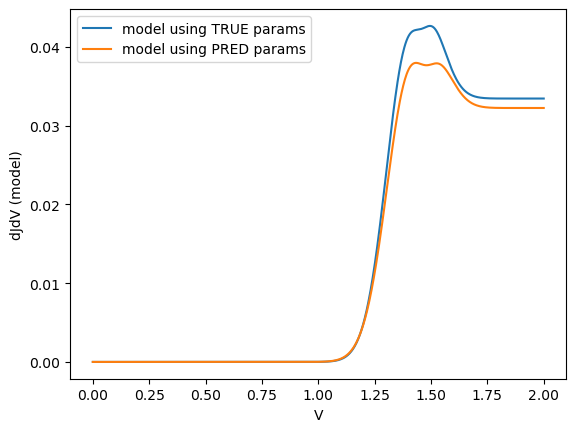

Pt          0.527300
Pd          0.117600
Au          0.323700
Ir          0.031400
k          14.933847
V0          1.619284
u1          1.263734
s1          0.052873
A1          0.027331
A2          0.008162
k_pred     11.265321
V0_pred     1.695996
u1_pred     1.268052
s1_pred     0.047726
A1_pred     0.053147
A2_pred     0.006570
Name: 1, dtype: float64


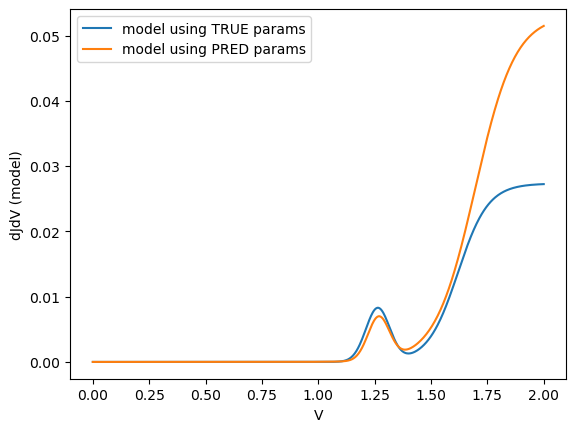

Pt          0.243500
Pd          0.138800
Au          0.531700
Ir          0.085900
k          12.214529
V0          1.744580
u1          1.341478
s1          0.057459
A1          0.075669
A2          0.005343
k_pred     12.261794
V0_pred     1.720628
u1_pred     1.321630
s1_pred     0.058591
A1_pred     0.059227
A2_pred     0.006770
Name: 2, dtype: float64


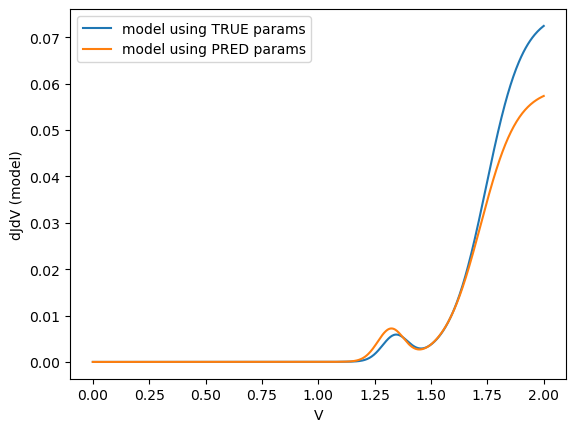

Pt          0.297300
Pd          0.116300
Au          0.513800
Ir          0.072600
k          11.275002
V0          1.710375
u1          1.338655
s1          0.064188
A1          0.047058
A2          0.004557
k_pred     11.681439
V0_pred     1.712674
u1_pred     1.306170
s1_pred     0.058319
A1_pred     0.052332
A2_pred     0.005249
Name: 3, dtype: float64


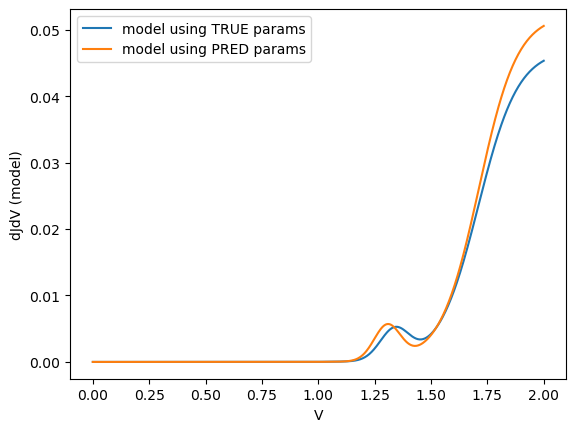

Pt          0.056000
Pd          0.505100
Au          0.195700
Ir          0.243200
k          10.959777
V0          1.671200
u1          1.388176
s1          0.072557
A1          0.065766
A2          0.021245
k_pred      8.072410
V0_pred     1.764687
u1_pred     1.392576
s1_pred     0.080578
A1_pred     0.080985
A2_pred     0.026018
Name: 4, dtype: float64


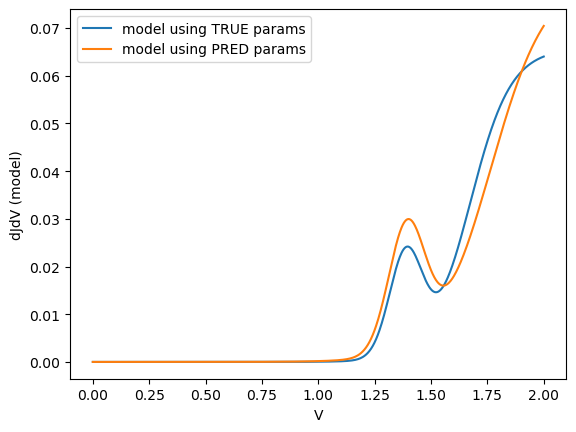

Pt         0.086800
Pd         0.086100
Au         0.555000
Ir         0.272100
k          3.360729
V0         2.000000
u1         1.421553
s1         0.080381
A1         0.080926
A2         0.019445
k_pred     7.472100
V0_pred    1.841066
u1_pred    1.397321
s1_pred    0.077535
A1_pred    0.087870
A2_pred    0.025827
Name: 5, dtype: float64


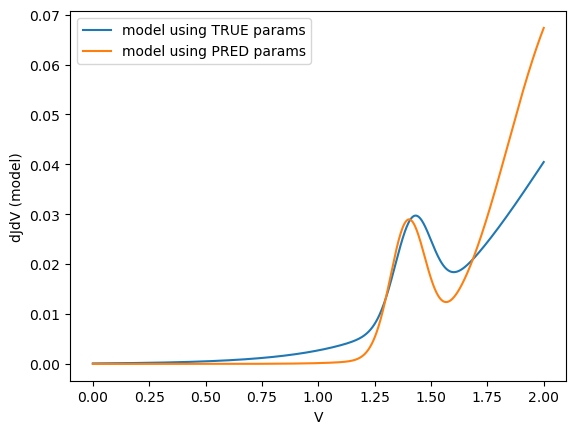

Pt          0.229900
Pd          0.145600
Au          0.511100
Ir          0.113500
k          11.313383
V0          1.745678
u1          1.333900
s1          0.053077
A1          0.069960
A2          0.005096
k_pred     11.880027
V0_pred     1.727747
u1_pred     1.365775
s1_pred     0.074754
A1_pred     0.064439
A2_pred     0.008292
Name: 6, dtype: float64


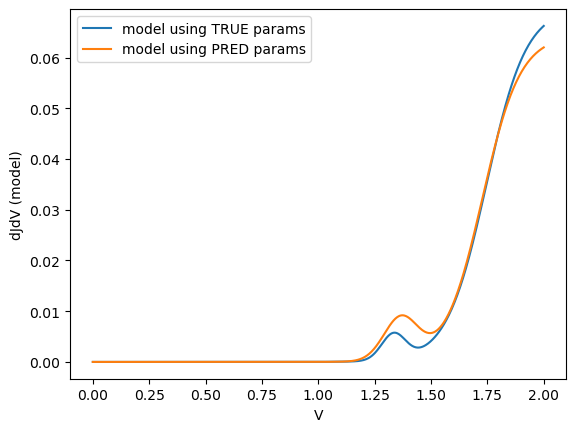

Pt         0.139700
Pd         0.092800
Au         0.611800
Ir         0.155600
k          4.226002
V0         2.000000
u1         1.384026
s1         0.052062
A1         0.083290
A2         0.011425
k_pred     9.788047
V0_pred    1.785753
u1_pred    1.372433
s1_pred    0.060871
A1_pred    0.074158
A2_pred    0.015444
Name: 7, dtype: float64


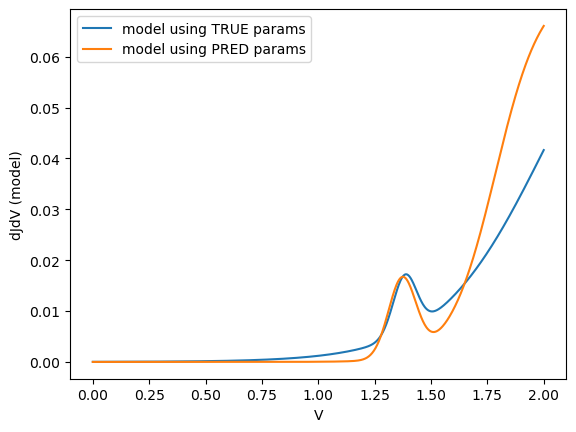

Pt          0.170400
Pd          0.223500
Au          0.099900
Ir          0.506200
k           8.022393
V0          1.670926
u1          1.428955
s1          0.116521
A1          0.054492
A2          0.033673
k_pred     22.770319
V0_pred     1.509365
u1_pred     1.398155
s1_pred     0.097326
A1_pred     0.037133
A2_pred     0.035112
Name: 8, dtype: float64


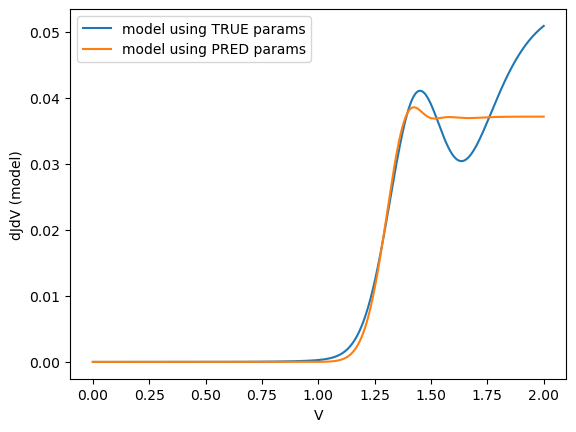

Pt          0.151500
Pd          0.073100
Au          0.073400
Ir          0.701900
k          17.434945
V0          1.568505
u1          1.446302
s1          0.128983
A1          0.026292
A2          0.034275
k_pred     27.262899
V0_pred     1.547369
u1_pred     1.429275
s1_pred     0.114438
A1_pred     0.032604
A2_pred     0.037825
Name: 9, dtype: float64


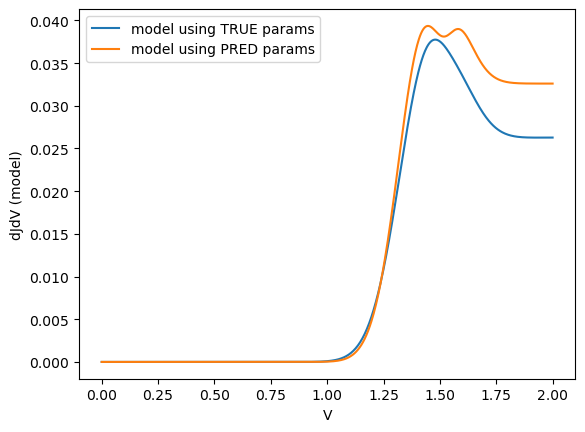

Pt         0.044700
Pd         0.337700
Au         0.314800
Ir         0.302800
k          7.075899
V0         1.685277
u1         1.398918
s1         0.086300
A1         0.069351
A2         0.033606
k_pred     7.060780
V0_pred    1.802341
u1_pred    1.403077
s1_pred    0.088938
A1_pred    0.087464
A2_pred    0.030384
Name: 10, dtype: float64


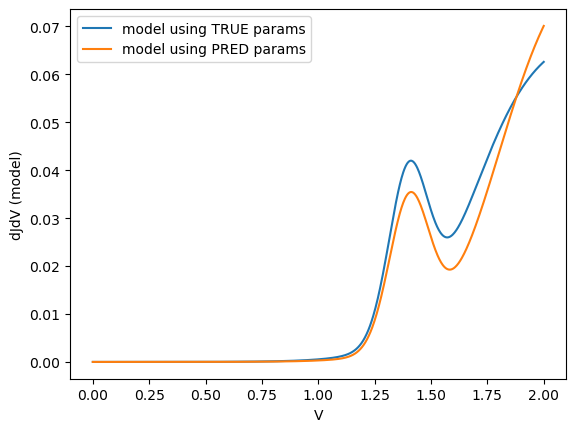

Pt          0.143800
Pd          0.239400
Au          0.478100
Ir          0.138700
k          12.717958
V0          1.703477
u1          1.365910
s1          0.068168
A1          0.067506
A2          0.014269
k_pred     11.530240
V0_pred     1.736026
u1_pred     1.361908
s1_pred     0.062166
A1_pred     0.073054
A2_pred     0.012164
Name: 11, dtype: float64


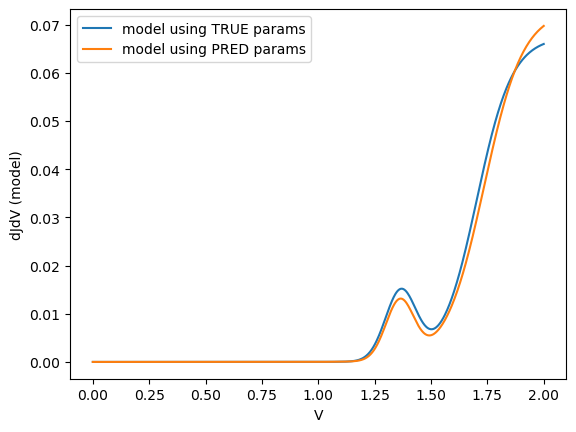

Pt          0.083100
Pd          0.097300
Au          0.482600
Ir          0.337000
k          17.381787
V0          1.475240
u1          1.398974
s1          0.095744
A1          0.026424
A2          0.026351
k_pred      8.122213
V0_pred     1.784984
u1_pred     1.405720
s1_pred     0.088291
A1_pred     0.077290
A2_pred     0.029621
Name: 12, dtype: float64


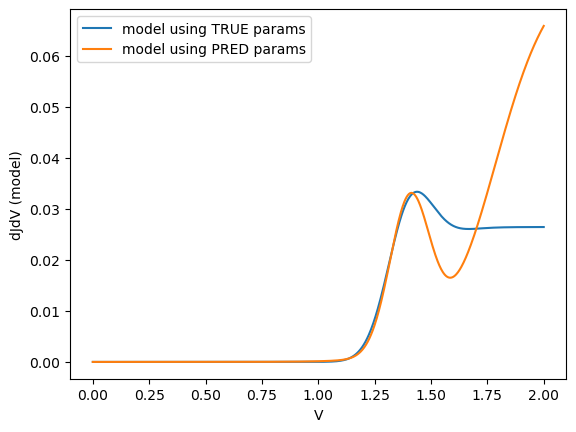

Pt          0.296300
Pd          0.103100
Au          0.519100
Ir          0.081500
k          10.394871
V0          1.729128
u1          1.296484
s1          0.056565
A1          0.064592
A2          0.005094
k_pred     11.619827
V0_pred     1.714277
u1_pred     1.306451
s1_pred     0.057893
A1_pred     0.053903
A2_pred     0.005287
Name: 13, dtype: float64


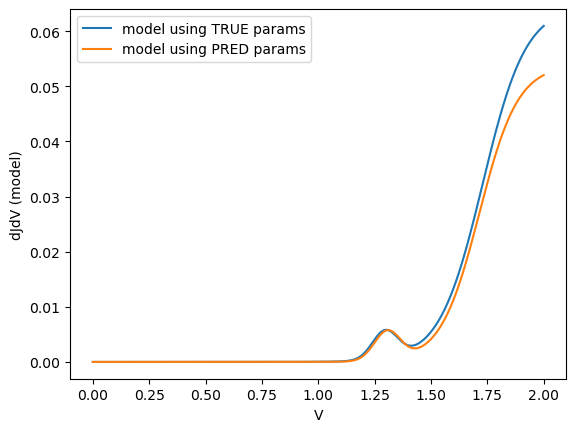

Pt          0.233100
Pd          0.357800
Au          0.319600
Ir          0.089500
k          12.082196
V0          1.709472
u1          1.361421
s1          0.079832
A1          0.061877
A2          0.020411
k_pred     15.078180
V0_pred     1.708504
u1_pred     1.315904
s1_pred     0.076311
A1_pred     0.057821
A2_pred     0.013147
Name: 14, dtype: float64


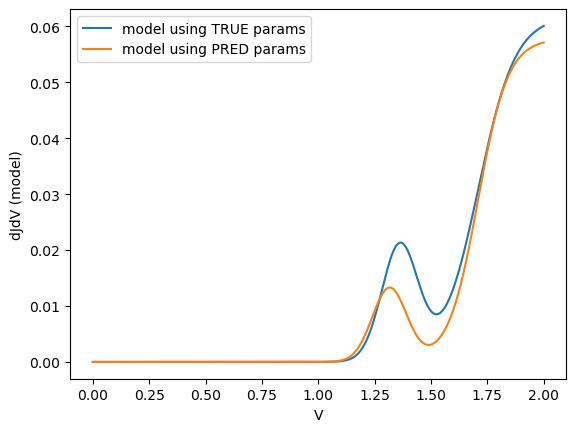

Pt          0.032500
Pd          0.148500
Au          0.381800
Ir          0.437200
k           8.045539
V0          1.613994
u1          1.424208
s1          0.107395
A1          0.048037
A2          0.037028
k_pred     23.801500
V0_pred     1.513015
u1_pred     1.398440
s1_pred     0.098865
A1_pred     0.036860
A2_pred     0.034923
Name: 15, dtype: float64


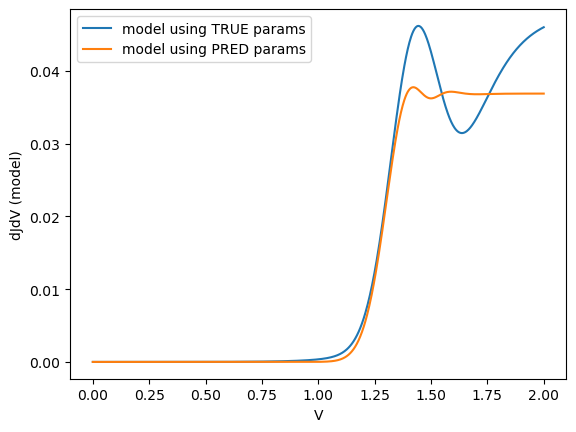

Pt          0.121600
Pd          0.210100
Au          0.138800
Ir          0.529600
k          10.045988
V0          1.561324
u1          1.410603
s1          0.102317
A1          0.028978
A2          0.023298
k_pred     21.179191
V0_pred     1.507793
u1_pred     1.401977
s1_pred     0.101027
A1_pred     0.035652
A2_pred     0.035248
Name: 16, dtype: float64


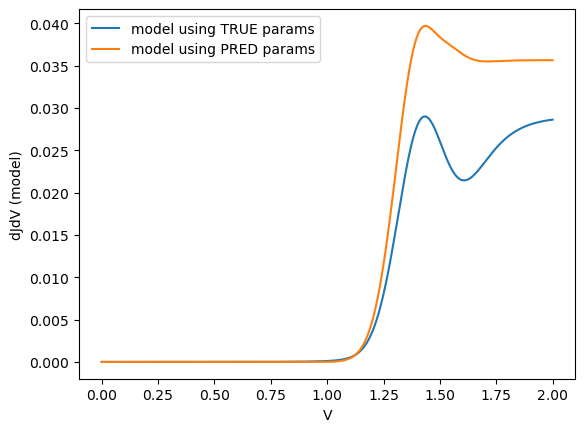

Pt          0.101500
Pd          0.182100
Au          0.319300
Ir          0.397200
k           6.080744
V0          1.716075
u1          1.412224
s1          0.099437
A1          0.058960
A2          0.029262
k_pred     14.977743
V0_pred     1.617106
u1_pred     1.404272
s1_pred     0.098129
A1_pred     0.051601
A2_pred     0.031960
Name: 17, dtype: float64


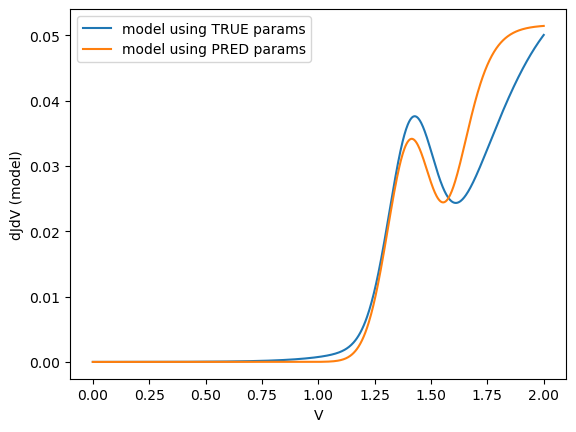

Pt          0.309700
Pd          0.233500
Au          0.046800
Ir          0.410100
k          10.353733
V0          1.562743
u1          1.402330
s1          0.097530
A1          0.036035
A2          0.024204
k_pred     10.015580
V0_pred     1.631570
u1_pred     1.406888
s1_pred     0.099451
A1_pred     0.054279
A2_pred     0.030822
Name: 18, dtype: float64


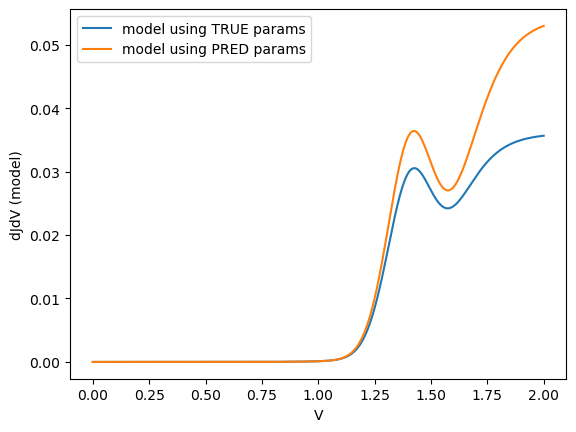

Pt          0.175100
Pd          0.128900
Au          0.569100
Ir          0.126900
k          10.993314
V0          1.692659
u1          1.368026
s1          0.055488
A1          0.038178
A2          0.010789
k_pred     11.684998
V0_pred     1.731670
u1_pred     1.358634
s1_pred     0.055191
A1_pred     0.068792
A2_pred     0.010509
Name: 19, dtype: float64


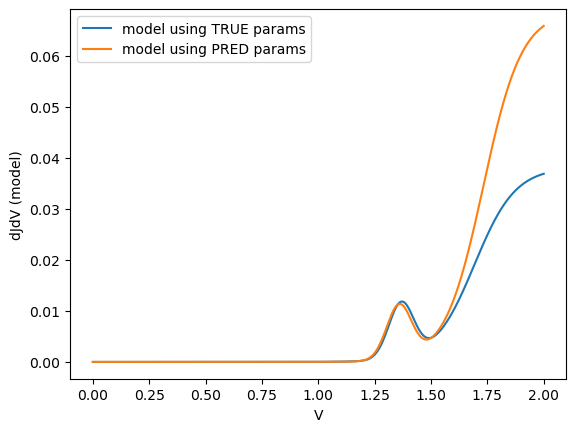

Pt          0.257300
Pd          0.078200
Au          0.582400
Ir          0.082100
k          12.277649
V0          1.701389
u1          1.358143
s1          0.045074
A1          0.043835
A2          0.005091
k_pred     12.340163
V0_pred     1.713603
u1_pred     1.317956
s1_pred     0.058534
A1_pred     0.055003
A2_pred     0.006361
Name: 20, dtype: float64


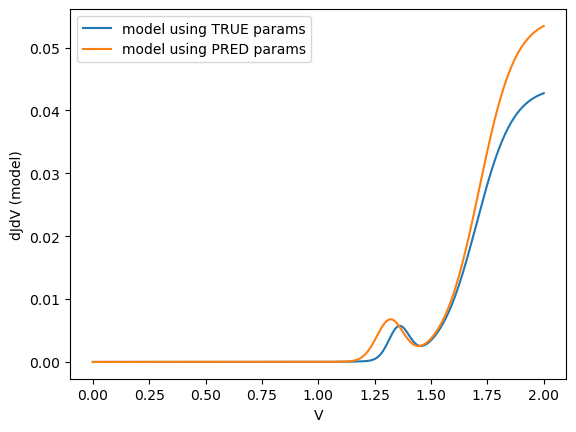

Pt          0.110000
Pd          0.105600
Au          0.625200
Ir          0.159100
k          13.024556
V0          1.710037
u1          1.371744
s1          0.051970
A1          0.071478
A2          0.016034
k_pred      9.635500
V0_pred     1.793555
u1_pred     1.375089
s1_pred     0.061940
A1_pred     0.077212
A2_pred     0.016651
Name: 21, dtype: float64


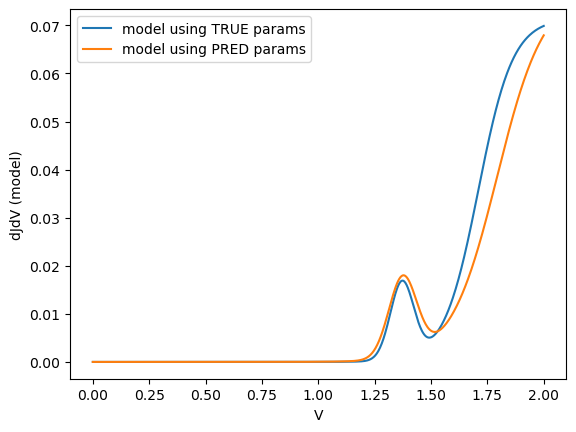

Pt         0.144400
Pd         0.337300
Au         0.364800
Ir         0.153500
k          3.560753
V0         2.000000
u1         1.385299
s1         0.081591
A1         0.099733
A2         0.022033
k_pred     9.604234
V0_pred    1.788637
u1_pred    1.377641
s1_pred    0.079578
A1_pred    0.081267
A2_pred    0.016068
Name: 22, dtype: float64


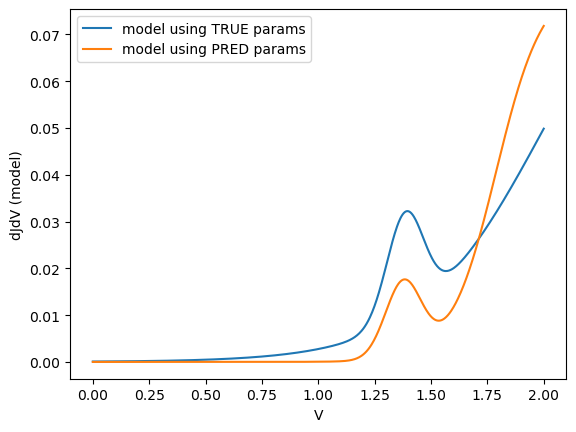

Pt          0.140600
Pd          0.142900
Au          0.463600
Ir          0.252900
k          10.689034
V0          1.698688
u1          1.374048
s1          0.068320
A1          0.063703
A2          0.022614
k_pred      8.116376
V0_pred     1.803895
u1_pred     1.391011
s1_pred     0.075885
A1_pred     0.080380
A2_pred     0.024073
Name: 23, dtype: float64


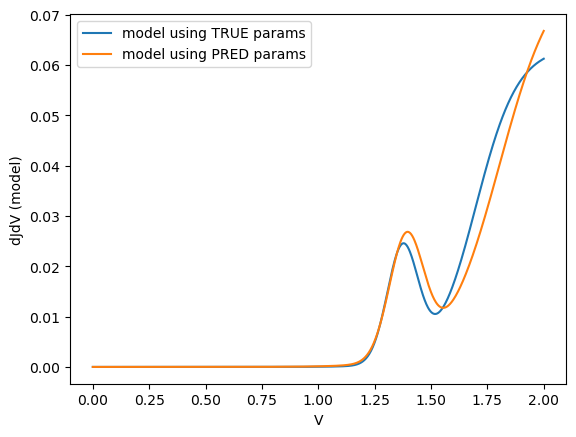

Pt         0.089700
Pd         0.232000
Au         0.364700
Ir         0.315300
k          3.096444
V0         2.000000
u1         1.460113
s1         0.116740
A1         0.090149
A2         0.024926
k_pred     6.976976
V0_pred    1.766096
u1_pred    1.404627
s1_pred    0.089630
A1_pred    0.074714
A2_pred    0.028068
Name: 24, dtype: float64


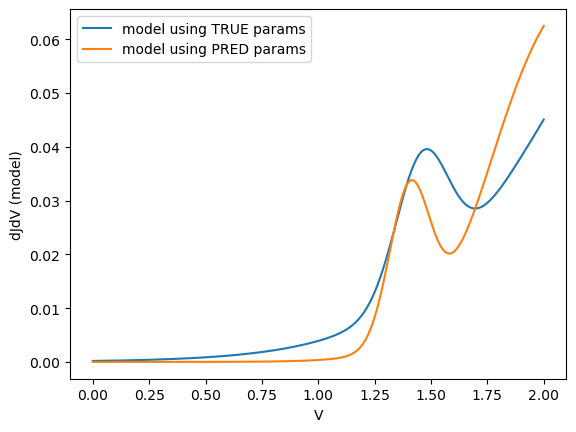

Pt         0.118900
Pd         0.249500
Au         0.333300
Ir         0.298300
k          4.334564
V0         2.000000
u1         1.392647
s1         0.082271
A1         0.141776
A2         0.028417
k_pred     7.204577
V0_pred    1.779153
u1_pred    1.397311
s1_pred    0.084198
A1_pred    0.078777
A2_pred    0.025882
Name: 25, dtype: float64


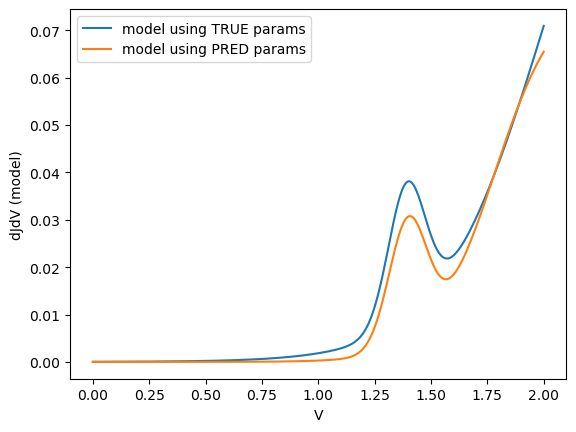

Pt          0.319400
Pd          0.360500
Au          0.265300
Ir          0.054900
k          11.860408
V0          1.707145
u1          1.273679
s1          0.054618
A1          0.068811
A2          0.010133
k_pred     13.471422
V0_pred     1.706651
u1_pred     1.285811
s1_pred     0.061553
A1_pred     0.055426
A2_pred     0.010937
Name: 26, dtype: float64


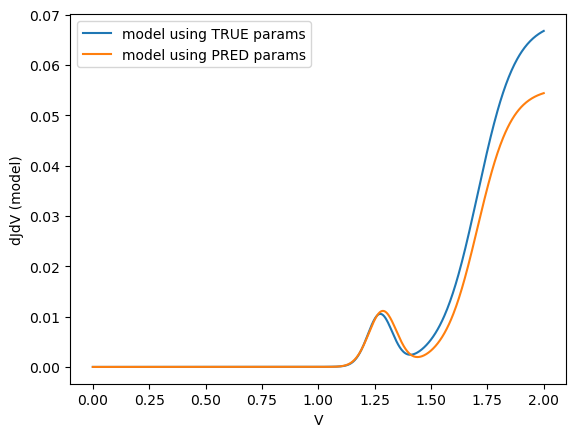

Pt          0.238000
Pd          0.090200
Au          0.581200
Ir          0.090500
k          11.265689
V0          1.738296
u1          1.344317
s1          0.045235
A1          0.067178
A2          0.004326
k_pred     12.186127
V0_pred     1.716604
u1_pred     1.326084
s1_pred     0.057160
A1_pred     0.057058
A2_pred     0.006155
Name: 27, dtype: float64


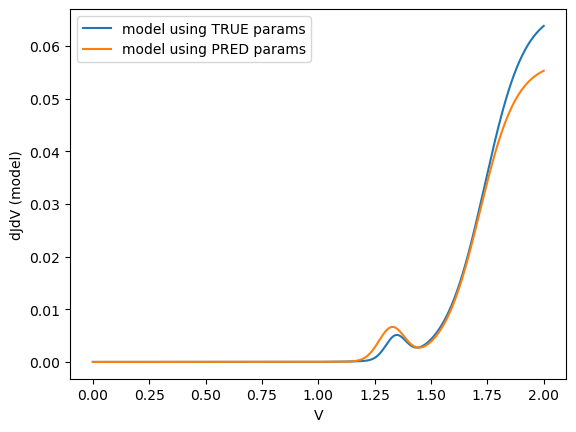

Pt         0.159900
Pd         0.245000
Au         0.448100
Ir         0.147100
k          4.598314
V0         2.000000
u1         1.366262
s1         0.049087
A1         0.118529
A2         0.010673
k_pred     9.990703
V0_pred    1.780499
u1_pred    1.371296
s1_pred    0.068159
A1_pred    0.075362
A2_pred    0.013948
Name: 28, dtype: float64


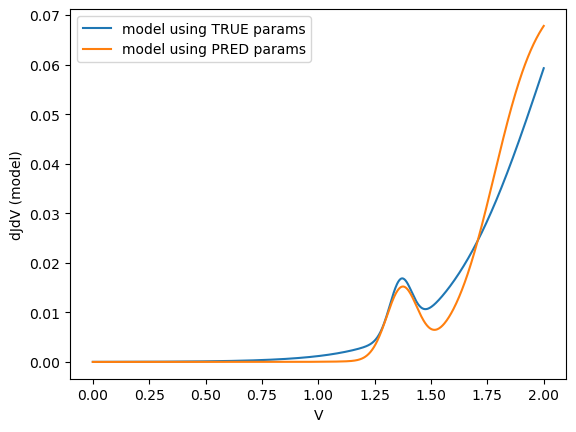

Pt          0.156800
Pd          0.094100
Au          0.582600
Ir          0.166500
k          11.961301
V0          1.703603
u1          1.365249
s1          0.052634
A1          0.065837
A2          0.017224
k_pred     10.085807
V0_pred     1.771925
u1_pred     1.372359
s1_pred     0.061272
A1_pred     0.070879
A2_pred     0.015572
Name: 29, dtype: float64


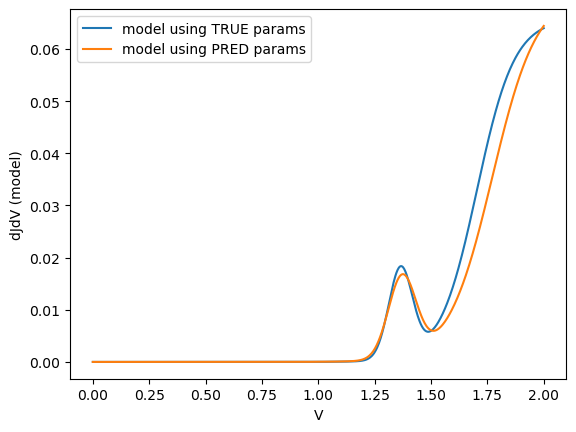

Pt         0.062400
Pd         0.376000
Au         0.230700
Ir         0.330900
k          8.284911
V0         1.551066
u1         1.401968
s1         0.087133
A1         0.052794
A2         0.030172
k_pred     7.033843
V0_pred    1.763806
u1_pred    1.405318
s1_pred    0.091610
A1_pred    0.080254
A2_pred    0.030858
Name: 30, dtype: float64


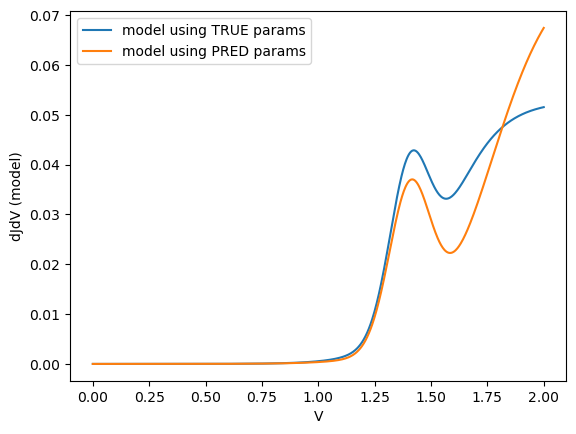

Pt          0.123200
Pd          0.067900
Au          0.659900
Ir          0.149000
k          12.897583
V0          1.688564
u1          1.375788
s1          0.054489
A1          0.044601
A2          0.014602
k_pred      9.834516
V0_pred     1.798258
u1_pred     1.372241
s1_pred     0.059267
A1_pred     0.080328
A2_pred     0.015082
Name: 31, dtype: float64


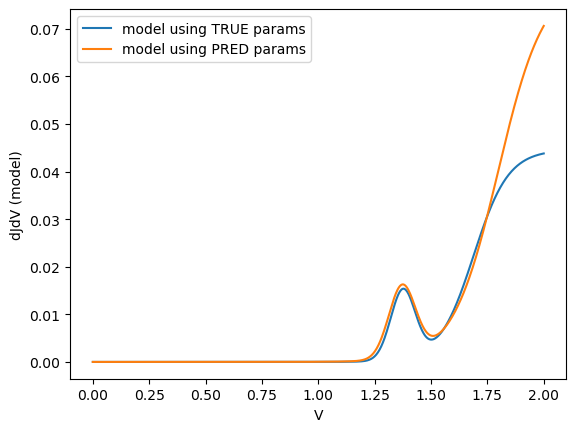

Pt          0.259100
Pd          0.162600
Au          0.064100
Ir          0.514200
k          12.638219
V0          1.523660
u1          1.408212
s1          0.101901
A1          0.035909
A2          0.034117
k_pred     21.590666
V0_pred     1.514290
u1_pred     1.405676
s1_pred     0.104389
A1_pred     0.033673
A2_pred     0.034815
Name: 32, dtype: float64


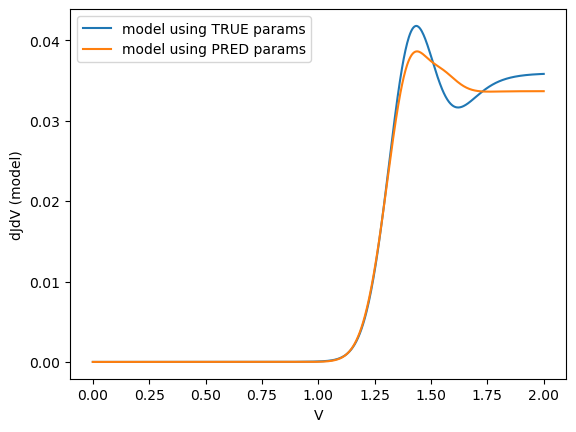

Pt          0.566500
Pd          0.095000
Au          0.316900
Ir          0.021600
k          10.929949
V0          1.625688
u1          1.282002
s1          0.051843
A1          0.021270
A2          0.002099
k_pred     11.408310
V0_pred     1.686564
u1_pred     1.270249
s1_pred     0.048318
A1_pred     0.050239
A2_pred     0.006318
Name: 33, dtype: float64


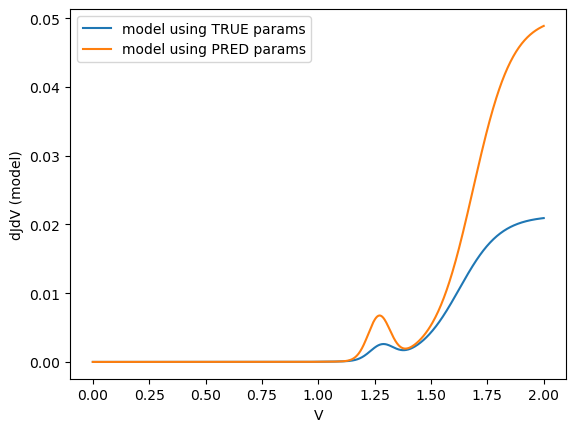

Pt          0.463600
Pd          0.097200
Au          0.399400
Ir          0.039800
k          10.515260
V0          1.707152
u1          1.279590
s1          0.038648
A1          0.060520
A2          0.002478
k_pred     11.695885
V0_pred     1.684688
u1_pred     1.281408
s1_pred     0.051448
A1_pred     0.044836
A2_pred     0.004992
Name: 34, dtype: float64


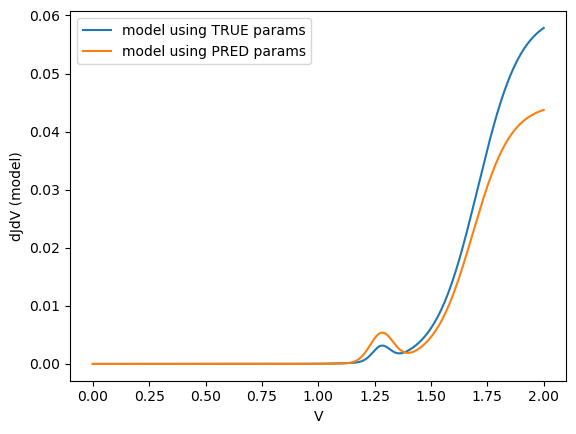

Pt          0.374200
Pd          0.114400
Au          0.455000
Ir          0.056400
k          15.203156
V0          1.692117
u1          1.273560
s1          0.066721
A1          0.051139
A2          0.017941
k_pred     11.569432
V0_pred     1.700838
u1_pred     1.295584
s1_pred     0.055663
A1_pred     0.048366
A2_pred     0.004798
Name: 35, dtype: float64


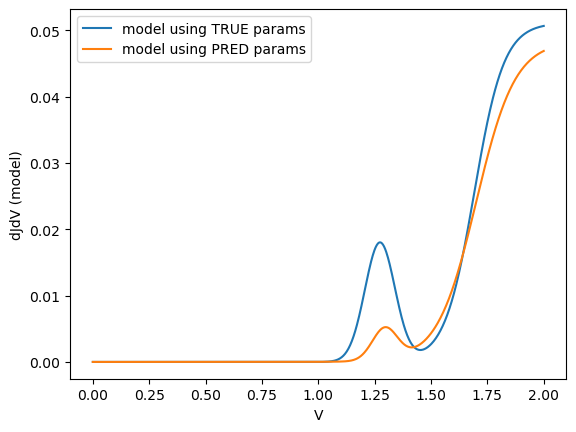

Pt          0.094300
Pd          0.095900
Au          0.119200
Ir          0.690600
k          25.855753
V0          1.567781
u1          1.440818
s1          0.124648
A1          0.038832
A2          0.046593
k_pred     27.715959
V0_pred     1.534411
u1_pred     1.422704
s1_pred     0.111086
A1_pred     0.032647
A2_pred     0.037536
Name: 36, dtype: float64


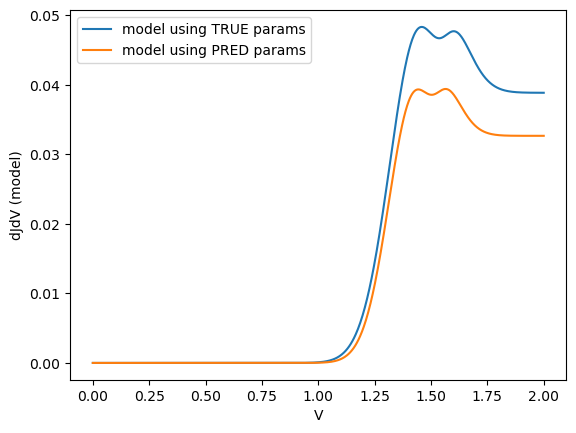

Pt          0.051200
Pd          0.072300
Au          0.463800
Ir          0.412700
k           8.624466
V0          1.650497
u1          1.431755
s1          0.110653
A1          0.053206
A2          0.045276
k_pred     22.389628
V0_pred     1.588142
u1_pred     1.401008
s1_pred     0.093262
A1_pred     0.049278
A2_pred     0.035147
Name: 37, dtype: float64


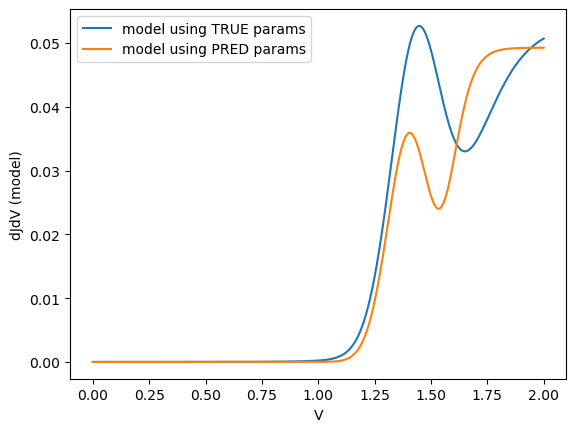

Pt          0.607600
Pd          0.124300
Au          0.255700
Ir          0.012400
k          10.208000
V0          1.688701
u1          1.263306
s1          0.042169
A1          0.044490
A2          0.003634
k_pred     11.347135
V0_pred     1.693081
u1_pred     1.267588
s1_pred     0.047882
A1_pred     0.052341
A2_pred     0.006825
Name: 38, dtype: float64


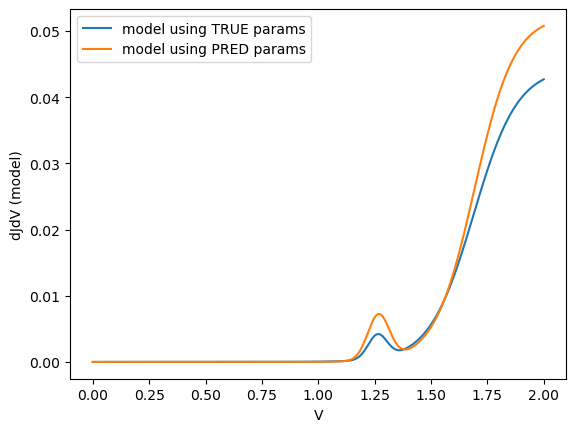

Pt          0.305000
Pd          0.088200
Au          0.044600
Ir          0.562100
k          28.433270
V0          1.400591
u1          1.326648
s1          0.073069
A1          0.022666
A2          0.010996
k_pred     25.356707
V0_pred     1.533231
u1_pred     1.419956
s1_pred     0.110698
A1_pred     0.032689
A2_pred     0.036685
Name: 39, dtype: float64


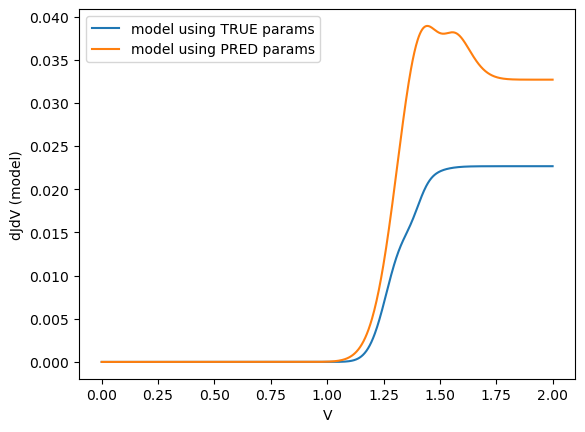

Pt          0.233100
Pd          0.357800
Au          0.319600
Ir          0.089500
k          12.812245
V0          1.689612
u1          1.375983
s1          0.083212
A1          0.063129
A2          0.026272
k_pred     15.078180
V0_pred     1.708504
u1_pred     1.315904
s1_pred     0.076311
A1_pred     0.057821
A2_pred     0.013147
Name: 40, dtype: float64


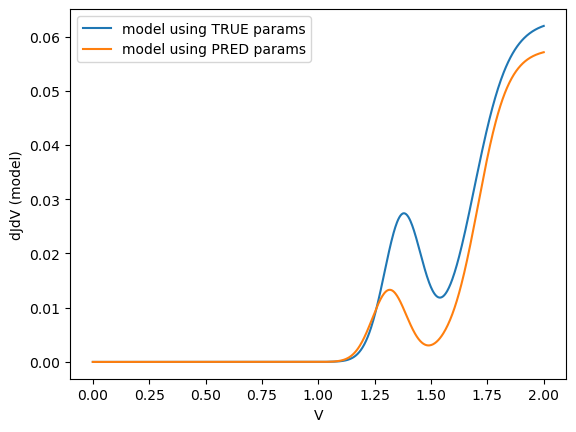

Pt          0.252900
Pd          0.147800
Au          0.511200
Ir          0.088100
k          11.638835
V0          1.700667
u1          1.356626
s1          0.051988
A1          0.038099
A2          0.004602
k_pred     12.230608
V0_pred     1.720181
u1_pred     1.319533
s1_pred     0.058788
A1_pred     0.059175
A2_pred     0.006823
Name: 41, dtype: float64


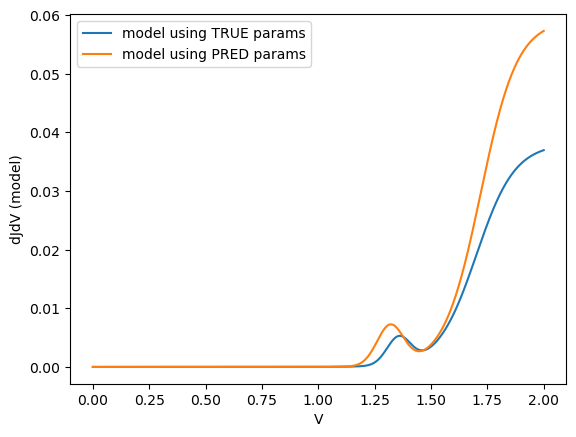

Pt          0.158900
Pd          0.189000
Au          0.459600
Ir          0.192400
k          11.213446
V0          1.701695
u1          1.365289
s1          0.067625
A1          0.066713
A2          0.021412
k_pred      9.272554
V0_pred     1.782418
u1_pred     1.381903
s1_pred     0.069457
A1_pred     0.076860
A2_pred     0.020820
Name: 42, dtype: float64


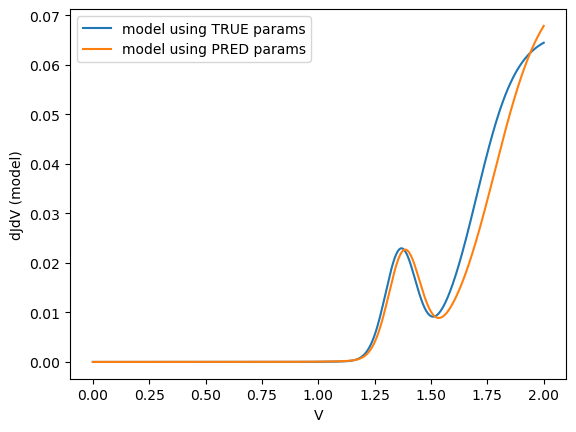

Pt          0.109000
Pd          0.300700
Au          0.157400
Ir          0.432900
k           9.579809
V0          1.599311
u1          1.416440
s1          0.102119
A1          0.043327
A2          0.026730
k_pred     12.526532
V0_pred     1.569578
u1_pred     1.407426
s1_pred     0.101108
A1_pred     0.045596
A2_pred     0.033242
Name: 43, dtype: float64


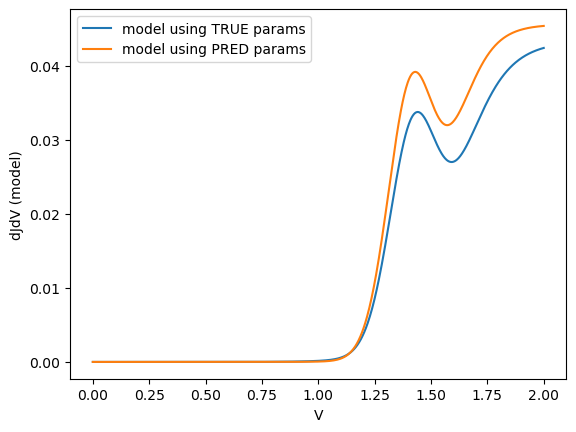

Pt         0.062800
Pd         0.101900
Au         0.504400
Ir         0.330900
k          7.959584
V0         1.571495
u1         1.420395
s1         0.095082
A1         0.044992
A2         0.030978
k_pred     8.926573
V0_pred    1.757626
u1_pred    1.407255
s1_pred    0.089383
A1_pred    0.073563
A2_pred    0.032304
Name: 44, dtype: float64


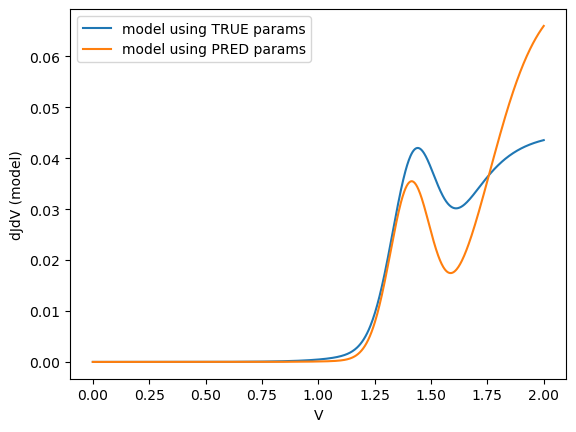

Pt          0.327500
Pd          0.151000
Au          0.445800
Ir          0.075800
k          10.178687
V0          1.742346
u1          1.298942
s1          0.051763
A1          0.059977
A2          0.003318
k_pred     11.628749
V0_pred     1.712531
u1_pred     1.301549
s1_pred     0.058130
A1_pred     0.053573
A2_pred     0.005559
Name: 45, dtype: float64


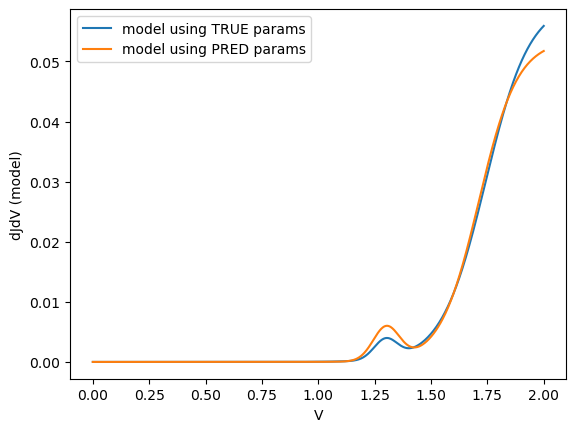

Pt          0.104000
Pd          0.070400
Au          0.095800
Ir          0.729800
k          27.364630
V0          1.565121
u1          1.443814
s1          0.122049
A1          0.034144
A2          0.041048
k_pred     27.445771
V0_pred     1.545882
u1_pred     1.428724
s1_pred     0.114142
A1_pred     0.032590
A2_pred     0.037866
Name: 46, dtype: float64


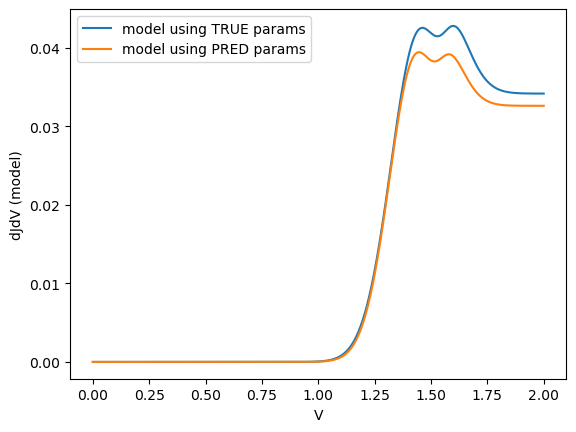

Pt          0.433500
Pd          0.198100
Au          0.328000
Ir          0.040300
k          12.414832
V0          1.709495
u1          1.283528
s1          0.042969
A1          0.041651
A2          0.004864
k_pred     11.055956
V0_pred     1.709476
u1_pred     1.267386
s1_pred     0.048358
A1_pred     0.058033
A2_pred     0.007631
Name: 47, dtype: float64


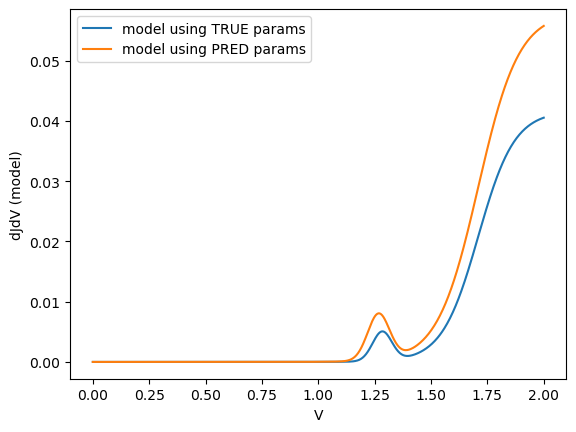

Pt          0.195100
Pd          0.354500
Au          0.347000
Ir          0.103500
k          10.926329
V0          1.692105
u1          1.341441
s1          0.075692
A1          0.050803
A2          0.012308
k_pred     13.114265
V0_pred     1.721134
u1_pred     1.375231
s1_pred     0.110923
A1_pred     0.064493
A2_pred     0.009349
Name: 48, dtype: float64


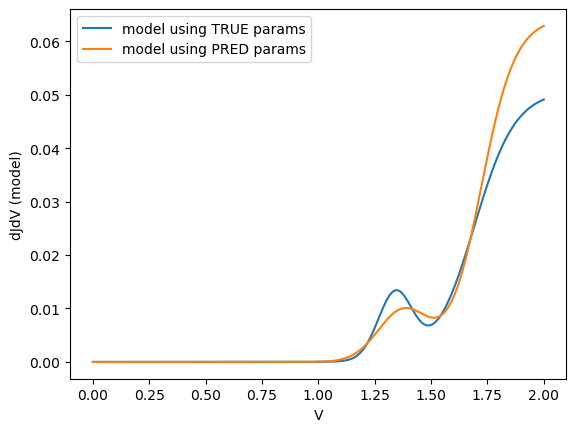

Pt          0.063900
Pd          0.095700
Au          0.163800
Ir          0.676600
k          29.175629
V0          1.501760
u1          1.403815
s1          0.102732
A1          0.040100
A2          0.041484
k_pred     27.923783
V0_pred     1.531769
u1_pred     1.421396
s1_pred     0.110429
A1_pred     0.032684
A2_pred     0.037503
Name: 49, dtype: float64


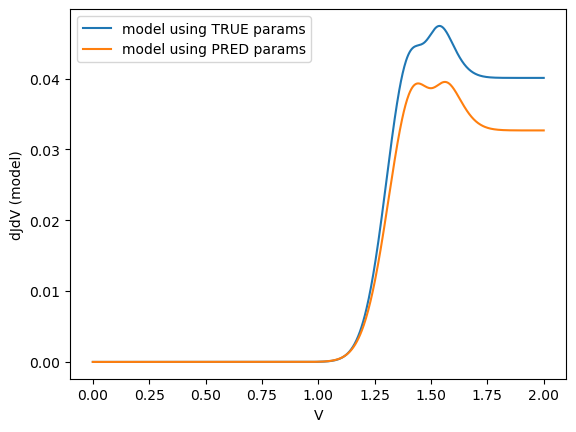

In [3]:
import matplotlib.pyplot as plt

def logistic(V, k, V0):
    return 1.0 / (1.0 + np.exp(-k * (V - V0)))

def hump(V, u, s):
    return np.exp(-((V - u) ** 2) / (2.0 * s ** 2))

def mathmodel(V, p):
    k, V0, u1, s1, A1, A2 = p
    S = logistic(V, k, V0)
    H1 = hump(V, u1, s1)
    return A1 * S + A2 * H1

def residuals(p, V, y):
    return mathmodel(V, p) - y

TRUE_COLS = ["k","V0","u1","s1","A1","A2"]
PRED_COLS = ["k_pred","V0_pred","u1_pred","s1_pred","A1_pred","A2_pred"]
def plot_row_models(row, Vgrid=None, Vmin=None, Vmax=None, npts=800):
    # choose a voltage grid
    if Vgrid is None:
        if Vmin is None or Vmax is None:
            raise ValueError("Provide Vgrid, or provide Vmin and Vmax.")
        Vgrid = np.linspace(Vmin, Vmax, npts)

    p_true = row[TRUE_COLS].to_numpy(dtype=float)
    p_pred = row[PRED_COLS].to_numpy(dtype=float)

    y_true = mathmodel(Vgrid, p_true)
    y_pred = mathmodel(Vgrid, p_pred)

    plt.figure()
    plt.plot(Vgrid, y_true, label="model using TRUE params")
    plt.plot(Vgrid, y_pred, label="model using PRED params")
    plt.xlabel("V")
    plt.ylabel("dJdV (model)")
    if "sample_id" in row.index:
        plt.title(f"sample_id={int(row['sample_id'])}")
    plt.legend()
    plt.show()

Vmin, Vmax = 0.0, 2.0
for _, row in results_df.iterrows():
    print(row)
    plot_row_models(row, Vmin=Vmin, Vmax=Vmax)

['Pt', 'Pd', 'Au', 'Ir']


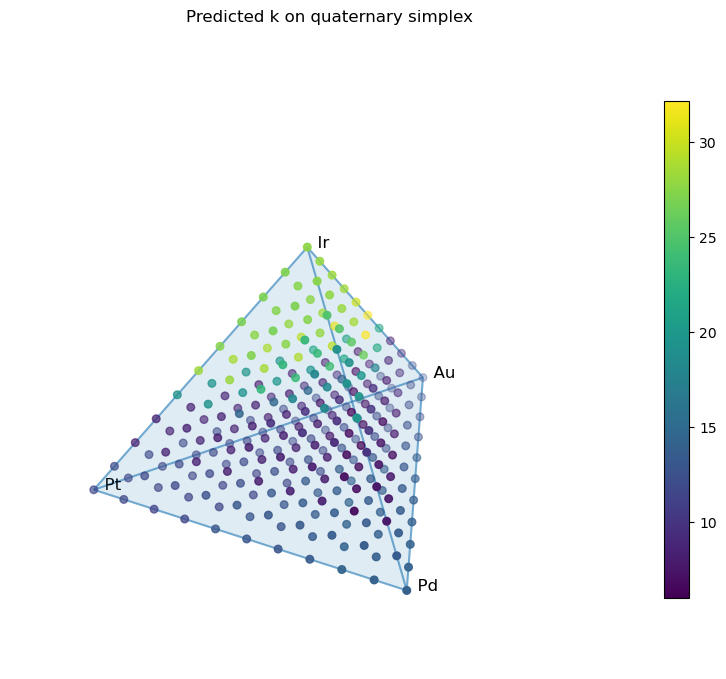

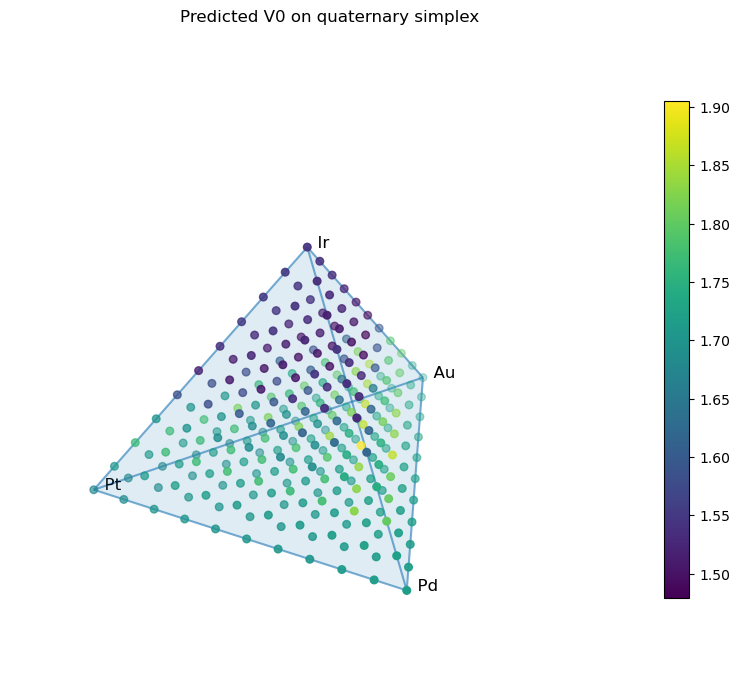

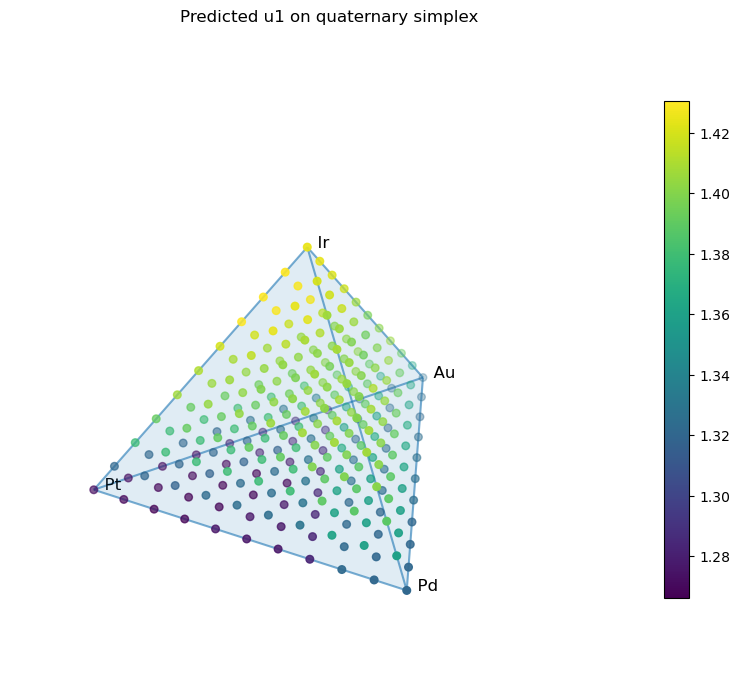

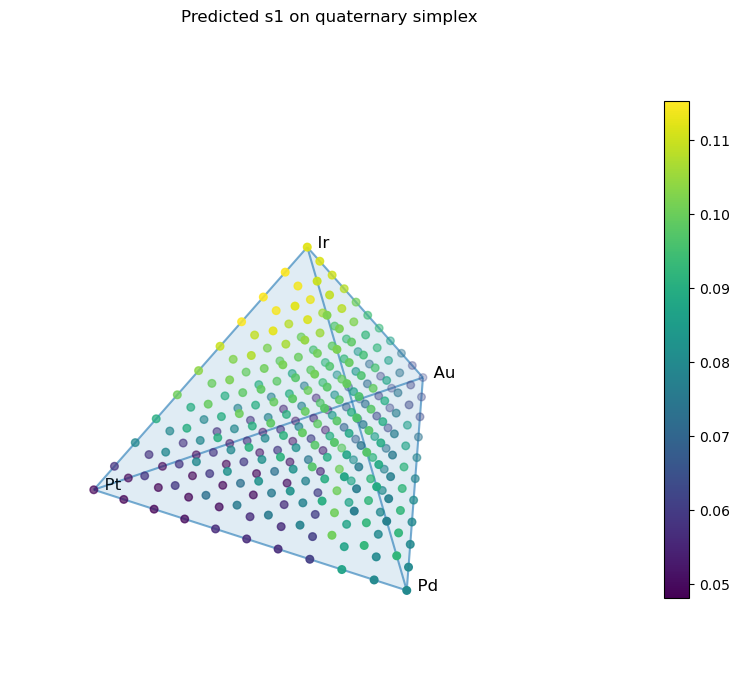

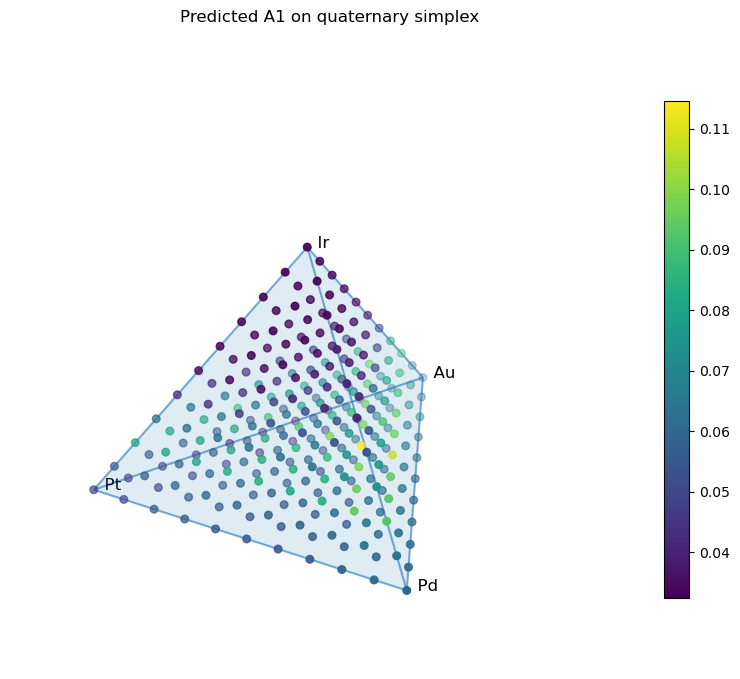

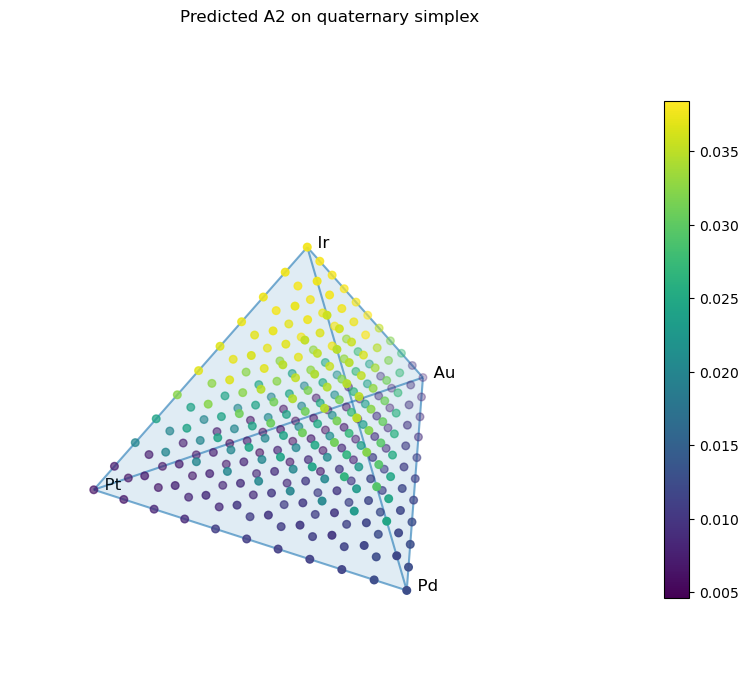

In [4]:
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

#tetrahedron
sqrt3 = np.sqrt(3.0)
V_Pt = np.array([0.0, 0.0, 0.0])
V_Pd = np.array([1.0, 0.0, 0.0])
V_Au = np.array([0.5, sqrt3/2, 0.0])
V_Ir = np.array([0.5, sqrt3/6, np.sqrt(2.0/3.0)])

V = np.stack([V_Pt, V_Pd, V_Au, V_Ir], axis=0)  # (4,3)

def simplex_lattice(step=0.1):
    """Return all 4-tuples on the quaternary simplex with given step size."""
    n = int(round(1.0 / step))
    comps = []
    for a in range(n+1):
        for b in range(n+1-a):
            for c in range(n+1-a-b):
                d = n - a - b - c
                comps.append([a, b, c, d])
    comps = np.array(comps, dtype=float) / n
    return comps  # shape (N,4), rows sum to 1

def barycentric_to_cartesian(comps):
    """comps: (N,4) where each row sums to 1, ordered [Pt, Pd, Au, Ir] returns (N,3)"""
    return comps @ V  # linear combo of tetra vertices

# ---- Build grid ----
comps = simplex_lattice(step=0.1)   # (286,4)
xyz = barycentric_to_cartesian(comps)

def plot_quaternary_tetra(xyz, values, title, V, ax=None, cmap="viridis", s=30):
    from mpl_toolkits.mplot3d.art3d import Poly3DCollection, Line3DCollection

    if ax is None:
        fig = plt.figure(figsize=(8, 7))
        ax = fig.add_subplot(111, projection='3d')

    # Unpack vertices in same order as V = [Pt,Pd,Au,Ir]
    V_Pt, V_Pd, V_Au, V_Ir = V

    edges = [
        (V_Pt, V_Pd), (V_Pt, V_Au), (V_Pt, V_Ir),
        (V_Pd, V_Au), (V_Pd, V_Ir),
        (V_Au, V_Ir)
    ]
    ax.add_collection3d(Line3DCollection(edges, linewidths=1.5, alpha=0.6))

    faces = [
        [V_Pt, V_Pd, V_Au],
        [V_Pt, V_Pd, V_Ir],
        [V_Pt, V_Au, V_Ir],
        [V_Pd, V_Au, V_Ir],
    ]
    ax.add_collection3d(Poly3DCollection(faces, alpha=0.07))

    # scatter with colors
    norm = Normalize(vmin=np.nanmin(values), vmax=np.nanmax(values))
    sc = ax.scatter(xyz[:,0], xyz[:,1], xyz[:,2],
                    c=values, cmap=cmap, norm=norm, s=s, depthshade=True)

    # labels
    for lab, vert in zip(["Pt","Pd","Au","Ir"], V):
        ax.text(vert[0], vert[1], vert[2], f"  {lab}", fontsize=12)

    ax.set_axis_off()
    ax.set_title(title)

    plt.colorbar(ScalarMappable(norm=norm, cmap=cmap), ax=ax, shrink=0.75, pad=0.02)

    return ax

# ---- Predict on lattice once ----
X_lattice = pd.DataFrame(comps, columns=X_cols)
print(X_lattice.columns.tolist())
Y_pred = best_model.predict(X_lattice.values)  # (N,6)

# ---- Make 6 figures ----
for j, name in enumerate(y_cols):
    vals = Y_pred[:, j]
    fig = plt.figure(figsize=(8, 7))
    ax = fig.add_subplot(111, projection="3d")
    plot_quaternary_tetra(xyz, vals, title=f"Predicted {name} on quaternary simplex", V=V, ax=ax)
    plt.tight_layout()
    filename = f"quaternary_{name}.pdf"
    plt.savefig(filename, format="pdf", bbox_inches="tight")
    plt.show()